# Interfacial spectral function in semi-infinite junctions

`heterostructures.build(h1,h2)` joins two semi-infinite leads (optionally with a finite central
region in between) into a single junction; `HT.get_kdos()` gives the momentum-resolved spectral
function right at the interface, generalizing the surface spectral function of the previous
notebook to a genuine boundary between two different materials rather than a boundary with vacuum.
Below, two honeycomb leads with opposite sublattice-imbalance gaps (a domain wall in the mass term)
are joined, exposing interface-localized states inside the shared gap.

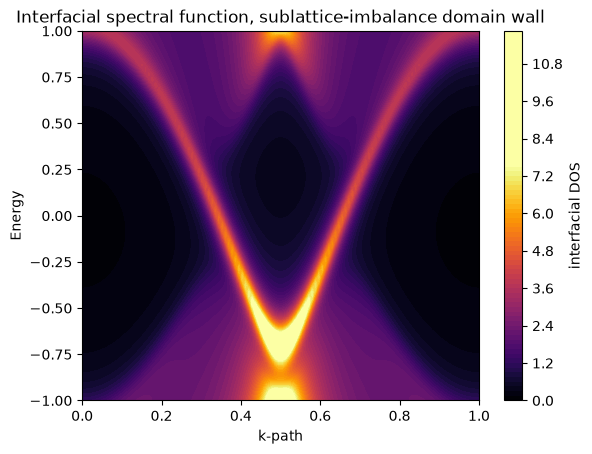

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry
from pyqula import heterostructures, parallel
parallel.set_cores(4) # HT.get_kdos does one Green's function solve per (k,e)

g = geometry.honeycomb_lattice()
h = g.get_hamiltonian()
h1 = h.copy() ; h1.add_sublattice_imbalance(0.3)
h2 = h.copy() ; h2.add_sublattice_imbalance(-0.3)
HT = heterostructures.build(h1,h2)
HT.delta = 1e-1
nk = 120
energies = np.linspace(-1,1,120)
(k,e,d) = HT.get_kdos(delta=1e-1,kpath=np.linspace(0,1,nk),energies=energies)
dgrid = d.reshape(nk,len(energies)).T

plt.contourf(np.unique(k),energies,dgrid,levels=100,cmap="inferno",vmax=np.percentile(dgrid,99))
plt.colorbar(label="interfacial DOS")
plt.xlabel("k-path") ; plt.ylabel("Energy")
plt.title("Interfacial spectral function, sublattice-imbalance domain wall")
plt.show()